# Stochastic Neural Network

Here we fit a stochastic neural network to two correlated outputs drawn from

$$ y_1(x) = \sin(\pi x) + \varepsilon_1 $$

and

$$
y_2(x) = \cos(\pi x) + \varepsilon_2
$$ 

with small Gaussian noise terms. The surrogate is a single-hidden-layer `tanh` network

$$ \hat{\mathbf{y}}(x) = W_2 \sigma(W_1 x + b_1) + b_2 $$

whose final-layer weights obey stochastic priors so we can sample functions.

In [1]:
# Import statements
import matplotlib.pyplot as plt
import torch

from pypolymix.parameter_groups import IIDGaussianGroup, DeterministicGroup
from pypolymix.surrogate_models import NeuralNetwork
from pypolymix import StochasticModel

In [2]:
# Set random seed
_ = torch.manual_seed(2048)

We draw `num_samples = 30` inputs in $[-1, 1]$ and evaluate $y_1(x)$ and $y_2(x)$ as sinusoidal functions plus Gaussian noise, stacking them into a two-column tensor `Y`.

In [3]:
# Generate synthetic data
num_samples = 30
X = 2 * torch.rand(num_samples, 1) - 1
y1 = torch.sin(torch.pi * X) + 0.05 * torch.randn(X.shape)
y2 = torch.cos(torch.pi * X) + 0.05 * torch.randn(X.shape)
Y = torch.hstack((y1, y2))

Two scatter plots (one per output) help visualize the phase shift between $\sin$ and $\cos$ so we know what structure the neural network must reproduce.

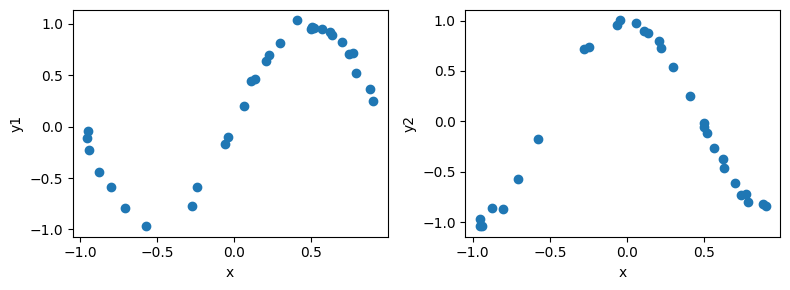

In [4]:
# Plot synthetic data
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (y, ax) in enumerate(zip(Y.T, axes.flatten())):
    ax.scatter(X, y)
    ax.set_xlabel("x")
    ax.set_ylabel(f"y{j + 1}")
plt.tight_layout()

We configure a width-16, depth-1 tanh network and print how many trainable parameters it contains so we have a sense of model capacity.

In [5]:
# Create a surrogate model
width = 16
depth = 1
surrogate_model = NeuralNetwork(num_inputs=1, num_outputs=2, width=width, depth=depth, activation=torch.nn.functional.tanh)
num_params = surrogate_model.num_params()
print(f"This model has {num_params} parameters")

This model has 66 parameters


All weights/biases up through the hidden layer are treated as deterministic, while the output-layer weights and biases follow i.i.d. Gaussian priors. This split lets us capture uncertainty primarily in the mapping from hidden features to the outputs, similar to a Bayesian neural network in the "Bayesian in the last layer" configuration.

In [6]:
# Create parameter groups
parameter_groups = [  # Input layer
    DeterministicGroup("input_layer_weights", width),
    DeterministicGroup("input_layer_biases", width),
]
for j in range(depth - 1):
    parameter_groups += [  # Hidden layers
        DeterministicGroup(f"layer{j + 1}_weights", width * width),
        DeterministicGroup(f"layer{j + 1}_biases", width),
    ]
parameter_groups += [  # Output layer
    IIDGaussianGroup("output_weights", 2 * width),
    IIDGaussianGroup("output_biases", 2),
]

The `StochasticModel` pairs the deterministic neural network with the grouped parameters so that sampling, log-prior penalties, and inference utilities become available.

In [7]:
# Create stochastic model
model = StochasticModel(
    surrogate_model=surrogate_model, parameter_groups=parameter_groups
)
print(f"Created stochastic model with {model.num_params()} parameters")

Created stochastic model with 66 parameters


We pick learning-rate and weight-decay values, set a small `weight_factor` for the distribution loss, introduce a learnable log-precision `log_tau`, and build the AdamW optimizer plus `OneCycleLR` scheduler.

In [8]:
# Training options
lr = 1e-3             # Learning rate
weight_decay = 1e-4   # Weight decay for AdamW
weight_factor = 1e-2  # Weight factor for distribution loss
num_epochs = 10000    # Number of epochs
num_samples = 100     # Number of parameter samples per epoch

# Learnable global precision
log_tau = torch.nn.Parameter(torch.tensor(0.0))  # τ = exp(log_tau)

# Optimizer: AdamW
optimizer = torch.optim.AdamW(
    list(model.parameters()) + [log_tau], lr=lr, weight_decay=weight_decay
)

# Loss
loss_fn = torch.nn.MSELoss(reduction="sum")

# Scheduler: OneCycleLR
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=10 * lr,
    total_steps=num_epochs
)

Each epoch samples 100 parameter realizations, evaluates the network, computes the precision-scaled MSE on the predictive mean, adds the distribution regularizer, and performs backpropagation followed by the optimizer/scheduler updates.

In [9]:
# Train the stochastic model
for epoch in range(num_epochs):
    optimizer.zero_grad()

    # Evaluate parameters and model
    params = model.sample_parameters(num_samples=100)
    Y_hat = surrogate_model(X, params)

    # Losses
    data_loss = loss_fn(Y_hat, Y.unsqueeze(0).expand_as(Y_hat)) / num_samples
    data_loss *= torch.exp(log_tau)
    distribution_loss = model.distribution_loss()
    total_loss = data_loss + weight_factor * distribution_loss

    # Backprop + step
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if (epoch + 1) % 1000 == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch + 1:5d} | "
            f"learning rate = {current_lr:.6f} | "
            f"data loss = {data_loss.item():.4f} | "
            f"distribution loss = {distribution_loss.item():.4f} | "
            f"total loss = {total_loss.item():.4f}"
        )

Epoch  1000 | learning rate = 0.002801 | data loss = 33.4647 | distribution loss = 79.6132 | total loss = 34.2608
Epoch  2000 | learning rate = 0.007603 | data loss = 3.9910 | distribution loss = 89.9401 | total loss = 4.8904
Epoch  3000 | learning rate = 0.010000 | data loss = 1.1182 | distribution loss = 98.5514 | total loss = 2.1037
Epoch  4000 | learning rate = 0.009504 | data loss = 0.4949 | distribution loss = 103.0698 | total loss = 1.5256
Epoch  5000 | learning rate = 0.008116 | data loss = 0.2993 | distribution loss = 104.3943 | total loss = 1.3432
Epoch  6000 | learning rate = 0.006110 | data loss = 0.2160 | distribution loss = 104.0745 | total loss = 1.2567
Epoch  7000 | learning rate = 0.003885 | data loss = 0.1736 | distribution loss = 102.8993 | total loss = 1.2026
Epoch  8000 | learning rate = 0.001881 | data loss = 0.1639 | distribution loss = 101.5564 | total loss = 1.1795
Epoch  9000 | learning rate = 0.000494 | data loss = 0.1493 | distribution loss = 100.6727 | tota

After training we switch to eval mode, create evenly spaced test points, and ask the stochastic model for 1000 posterior samples so we can estimate predictive uncertainty.

In [10]:
# Evaluate the model
model.eval()
with torch.no_grad():
    X_test = torch.linspace(-1, 1, 50).unsqueeze(1)
    Y_test = model(X_test, num_samples=1000)

For each output dimension we show the mean prediction and the central 90% credible interval obtained from the samples, plus the observed data for reference.

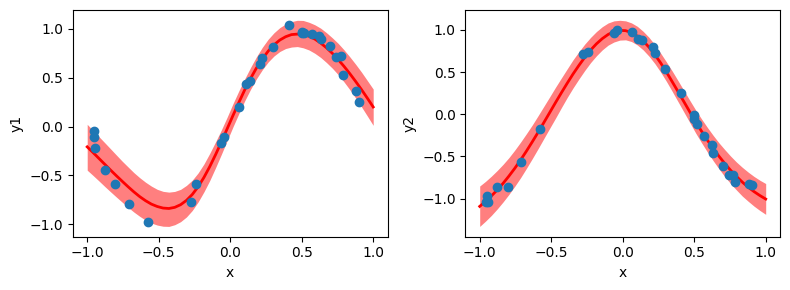

In [11]:
# Plot prediction
_, axes = plt.subplots(1, 2, figsize=(8, 3))
for j, (y, ax) in enumerate(zip(Y.T, axes.flatten())):
    x = X_test.squeeze(-1)
    q = torch.quantile(Y_test[:, :, j], torch.tensor([0.05, 0.5, 0.95]), axis=0)
    ax.fill_between(x, q[0], q[-1], color="red", alpha=0.5, linewidth=0)
    ax.plot(x, q[1], color="red", linewidth=2)
    ax.scatter(X, y, zorder=99)
    ax.set_xlabel("x")
    ax.set_ylabel(f"y{j + 1}")
plt.tight_layout()